In [1]:
import os
import hashlib

def get_image_hashes(folder_path):
    """
    Walks through all class folders and returns a dict of image content hashes.
    Format: {hash: [(folder, class_name, image_name), ...]}
    """
    hashes = {}
    for class_name in os.listdir(folder_path):
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_dir):
            continue
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)
            try:
                with open(image_path, 'rb') as f:
                    image_bytes = f.read()
                    image_hash = hashlib.md5(image_bytes).hexdigest()
                    hashes.setdefault(image_hash, []).append((folder_path, class_name, image_name))
            except Exception as e:
                print(f"❗ Error reading {image_path}: {e}")
    return hashes

# === UPDATE THESE PATHS TO YOUR LOCAL FOLDERS ===
train_path = r"C:\Users\STUDENT\Downloads\FishDataset_Resized\train"
val_path = r"C:\Users\STUDENT\Downloads\FishDataset_Resized\val"
test_path = r"C:\Users\STUDENT\Downloads\FishDataset_Resized\test"

# Collect hashes
print("📥 Scanning images...")
train_hashes = get_image_hashes(train_path)
val_hashes = get_image_hashes(val_path)
test_hashes = get_image_hashes(test_path)

# Convert to sets for comparison
train_set = set(train_hashes.keys())
val_set = set(val_hashes.keys())
test_set = set(test_hashes.keys())

# Check for duplicates
leak_train_val = train_set & val_set
leak_train_test = train_set & test_set
leak_val_test = val_set & test_set

# Print results
print("\n🔍 Duplicate Image Check (based on file content):")
print(f"→ Train vs Val:  {len(leak_train_val)} duplicate images")
print(f"→ Train vs Test: {len(leak_train_test)} duplicate images")
print(f"→ Val vs Test:   {len(leak_val_test)} duplicate images")

# Optionally print file names of duplicates
if leak_train_test:
    print("\n🖼 Example duplicate(s) between Train and Test:")
    for h in list(leak_train_test)[:5]:
        print("Train:", train_hashes[h])
        print("Test: ", test_hashes[h])
        print("---")


📥 Scanning images...

🔍 Duplicate Image Check (based on file content):
→ Train vs Val:  2462 duplicate images
→ Train vs Test: 1404 duplicate images
→ Val vs Test:   294 duplicate images

🖼 Example duplicate(s) between Train and Test:
Train: [('C:\\Users\\STUDENT\\Downloads\\FishDataset_Resized\\train', 'Goby', '9a901dd9-6924-42a6-b82d-6c1ed95314ff-110mm.jpg')]
Test:  [('C:\\Users\\STUDENT\\Downloads\\FishDataset_Resized\\test', 'Goby', '9a901dd9-6924-42a6-b82d-6c1ed95314ff-110mm.jpg')]
---
Train: [('C:\\Users\\STUDENT\\Downloads\\FishDataset_Resized\\train', 'Grass Carp', 'Rohu_212_jpg.rf.b55170d31c92741b4cd0d73bd64cd5d0.jpg')]
Test:  [('C:\\Users\\STUDENT\\Downloads\\FishDataset_Resized\\test', 'Grass Carp', 'Rohu_212_jpg.rf.b55170d31c92741b4cd0d73bd64cd5d0.jpg')]
---
Train: [('C:\\Users\\STUDENT\\Downloads\\FishDataset_Resized\\train', 'Mosquito Fish', 'Picture632.jpg')]
Test:  [('C:\\Users\\STUDENT\\Downloads\\FishDataset_Resized\\test', 'Mosquito Fish', 'Picture632.jpg')]
---
Trai

In [5]:
import os
import shutil
import random
import hashlib
from tqdm import tqdm

# === Configuration ===
input_dir = r"C:\Users\STUDENT\Downloads\FishDataset_New"  # your folder with 31 class subfolders
output_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"  # where new folders will be created
split_ratios = (0.7, 0.15, 0.15)  # train, val, test

# === Setup ===
random.seed(42)
os.makedirs(output_dir, exist_ok=True)
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

# === Helper: Get file hash ===
def get_file_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# === Process all classes ===
all_hashes = set()

for class_name in tqdm(os.listdir(input_dir), desc="📂 Processing Classes"):
    class_path = os.path.join(input_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_images = []

    for img in images:
        full_path = os.path.join(class_path, img)
        img_hash = get_file_hash(full_path)

        # Skip duplicate image
        if img_hash in all_hashes:
            continue

        all_hashes.add(img_hash)
        class_images.append(full_path)

    # Shuffle and split
    random.shuffle(class_images)
    n = len(class_images)
    n_train = int(split_ratios[0] * n)
    n_val = int(split_ratios[1] * n)

    splits = {
        "train": class_images[:n_train],
        "val": class_images[n_train:n_train+n_val],
        "test": class_images[n_train+n_val:]
    }

    # Save to output directory
    for split_name, image_list in splits.items():
        split_class_dir = os.path.join(output_dir, split_name, class_name)
        os.makedirs(split_class_dir, exist_ok=True)
        for img_path in image_list:
            shutil.copy(img_path, os.path.join(split_class_dir, os.path.basename(img_path)))

print("\n✅ Dataset has been cleaned, shuffled, and split with no duplicates!")


📂 Processing Classes: 100%|██████████| 31/31 [00:10<00:00,  2.94it/s]


✅ Dataset has been cleaned, shuffled, and split with no duplicates!


In [49]:
import os
import hashlib

def get_image_hashes(folder_path):
    hashes = {}
    for class_name in os.listdir(folder_path):
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_dir):
            continue
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)
            try:
                with open(image_path, 'rb') as f:
                    image_bytes = f.read()
                    image_hash = hashlib.md5(image_bytes).hexdigest()
                    hashes.setdefault(image_hash, []).append((folder_path, class_name, image_name))
            except Exception as e:
                print(f"Error reading {image_path}: {e}")
    return hashes

# === Update to your cleaned split folders ===
base_path = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "val")
test_path = os.path.join(base_path, "test")

train_hashes = get_image_hashes(train_path)
val_hashes = get_image_hashes(val_path)
test_hashes = get_image_hashes(test_path)

train_set = set(train_hashes.keys())
val_set = set(val_hashes.keys())
test_set = set(test_hashes.keys())

leak_train_val = train_set & val_set
leak_train_test = train_set & test_set
leak_val_test = val_set & test_set

print("🔍 Final Duplicate Check:")
print(f"→ Train vs Val:  {len(leak_train_val)} duplicate images")
print(f"→ Train vs Test: {len(leak_train_test)} duplicate images")
print(f"→ Val vs Test:   {len(leak_val_test)} duplicate images")

# Show examples if found
if leak_train_test:
    print("\n🖼 Example duplicate(s) between Train and Test:")
    for h in list(leak_train_test)[:3]:
        print("Train:", train_hashes[h])
        print("Test: ", test_hashes[h])
        print("---")


🔍 Final Duplicate Check:
→ Train vs Val:  0 duplicate images
→ Train vs Test: 0 duplicate images
→ Val vs Test:   0 duplicate images


In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import timm

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ Updated path to cleaned dataset
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ✅ Load from split folders
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=test_val_transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=test_val_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Number of classes
num_classes = len(train_dataset.classes)


Using device: cuda


In [3]:
import torch.nn.functional as F  # ✅ Required for F.cross_entropy

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


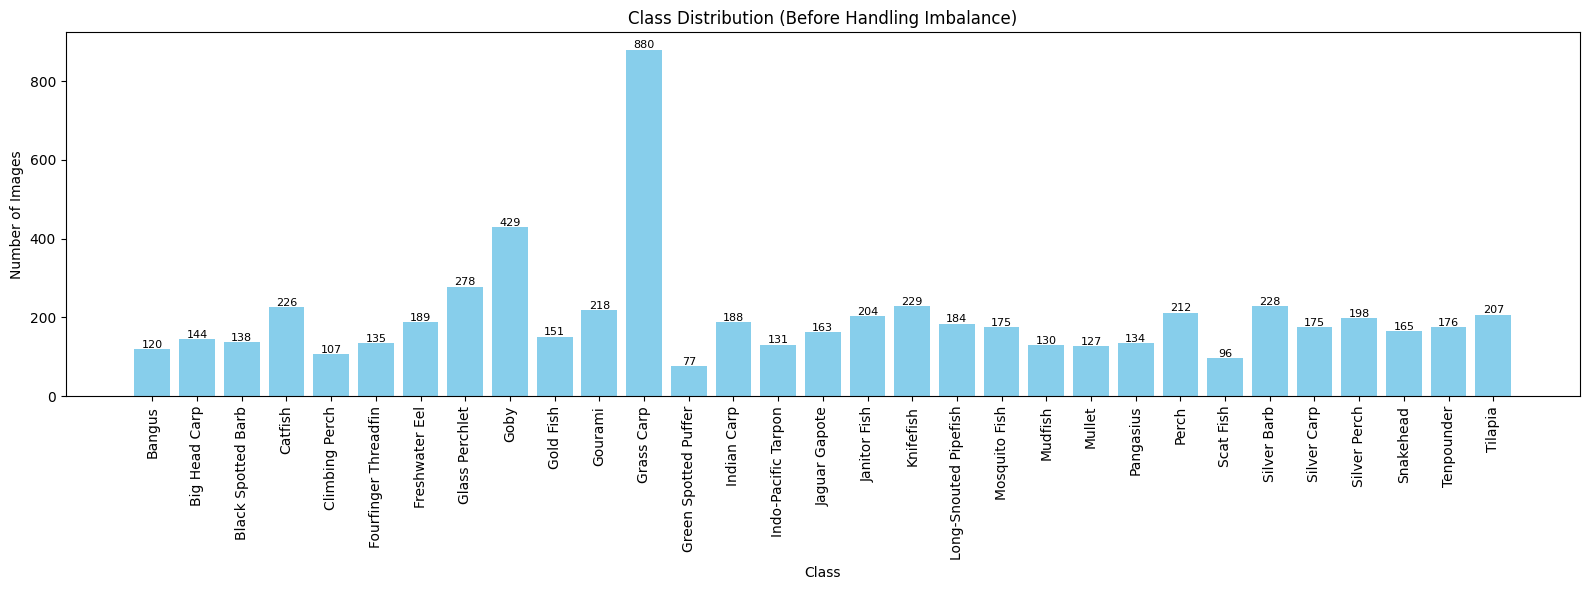

In [1]:
import os
import matplotlib.pyplot as plt

# Re-define the path to your dataset root
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"

# Now proceed with plotting
train_path = os.path.join(data_dir, "train")
class_names = sorted(os.listdir(train_path))
class_counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in class_names]

plt.figure(figsize=(16, 6))
plt.bar(class_names, class_counts, color='skyblue')
plt.xticks(rotation=90)
plt.title("Class Distribution (Before Handling Imbalance)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
for i, count in enumerate(class_counts):
    plt.text(i, count + 3, str(count), ha='center', fontsize=8)
plt.tight_layout()
plt.show()


In [4]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_counts = [len(os.listdir(os.path.join(data_dir, 'train', c)))
                for c in sorted(os.listdir(os.path.join(data_dir, 'train')))]

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.arange(len(class_counts)),
                                     y=np.concatenate([[i]*count for i, count in enumerate(class_counts)]))

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = FocalLoss(gamma=2.0, weight=class_weights)


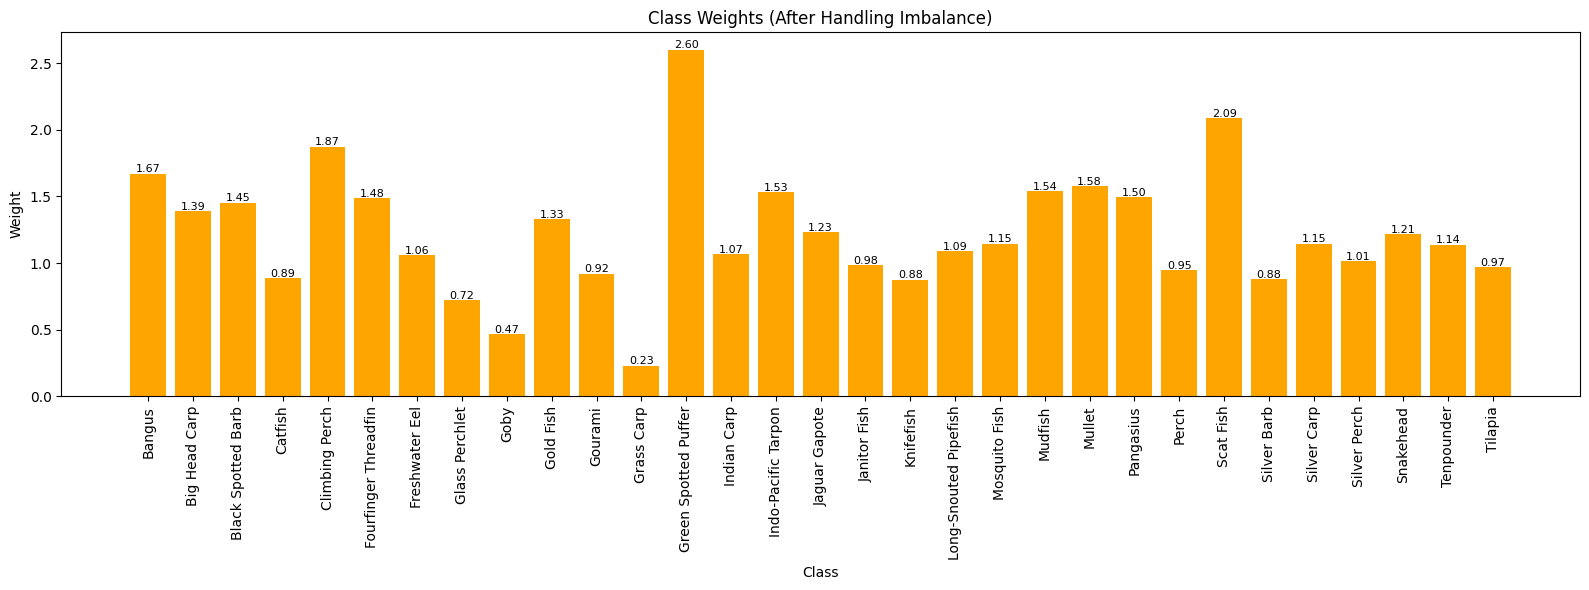

In [5]:
import numpy as np

# Already computed class_weights earlier
plt.figure(figsize=(16, 6))
plt.bar(class_names, class_weights.cpu().numpy(), color='orange')
plt.xticks(rotation=90)
plt.title("Class Weights (After Handling Imbalance)")
plt.xlabel("Class")
plt.ylabel("Weight")
for i, weight in enumerate(class_weights.cpu().numpy()):
    plt.text(i, weight + 0.01, f"{weight:.2f}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()


In [11]:
model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [12]:
def evaluate(model, dataloader):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = 100 * correct / total
    return avg_loss, acc

In [13]:
def train_model(model, train_loader, val_loader, epochs=30, patience=5):
    best_val_acc = 0.0
    best_epoch = 0
    early_stop_counter = 0

    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = train_loss / total
        train_acc = 100 * correct / total
        val_loss, val_acc = evaluate(model, val_loader)

        train_loss_history.append(avg_train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            early_stop_counter = 0
            torch.save(model.state_dict(), "best_fish_model(focal).pth")
            print(f"✅ Saved best model at epoch {epoch+1} with Val Acc: {val_acc:.2f}%")
        else:
            early_stop_counter += 1
            print(f"⏳ No improvement for {early_stop_counter} epoch(s)")

        # Print epoch results
        print(f"Epoch {epoch+1}:")
        print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

        # Stop if no improvement
        if early_stop_counter >= patience:
            print(f"🛑 Early stopping triggered after {patience} epochs without improvement.")
            break

    print(f"\n🏁 Best Val Acc: {best_val_acc:.2f}% at epoch {best_epoch+1}")
    return train_loss_history, train_acc_history, val_loss_history, val_acc_history


In [14]:
import time
import pickle

# Start timing ⏱️
start_time = time.time()

# Call the training function
train_loss, train_acc, val_loss, val_acc = train_model(model, train_loader, val_loader, epochs=250)

# End timing ⏱️
end_time = time.time()
elapsed = end_time - start_time

# Save history to pickle
history = {
    'train_loss': train_loss,
    'train_acc': train_acc,
    'val_loss': val_loss,
    'val_acc': val_acc
}

with open("training_history(focal).pkl", "wb") as f:
    pickle.dump(history, f)

print(f"✅ History saved to training_history(new).pkl")
print(f"🕒 Total training time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")


Epoch 1/250: 100%|██████████| 195/195 [00:55<00:00,  3.55it/s]


✅ Saved best model at epoch 1 with Val Acc: 80.09%
Epoch 1:
  Train Loss: 1.7571, Train Acc: 51.46%
  Val   Loss: 0.5438, Val   Acc: 80.09%


Epoch 2/250: 100%|██████████| 195/195 [01:09<00:00,  2.79it/s]


✅ Saved best model at epoch 2 with Val Acc: 88.53%
Epoch 2:
  Train Loss: 0.3419, Train Acc: 83.86%
  Val   Loss: 0.2610, Val   Acc: 88.53%


Epoch 3/250: 100%|██████████| 195/195 [01:15<00:00,  2.57it/s]


...

⏳ No improvement for 3 epoch(s)
Epoch 13:
  Train Loss: 0.0099, Train Acc: 98.55%
  Val   Loss: 0.1829, Val   Acc: 92.78%


Epoch 14/250: 100%|██████████| 195/195 [01:11<00:00,  2.71it/s]


⏳ No improvement for 4 epoch(s)
Epoch 14:
  Train Loss: 0.0115, Train Acc: 98.60%
  Val   Loss: 0.1881, Val   Acc: 93.16%


Epoch 15/250: 100%|██████████| 195/195 [01:13<00:00,  2.65it/s]


⏳ No improvement for 5 epoch(s)
Epoch 15:
  Train Loss: 0.0079, Train Acc: 98.73%
  Val   Loss: 0.1708, Val   Acc: 93.47%
🛑 Early stopping triggered after 5 epochs without improvement.

🏁 Best Val Acc: 93.62% at epoch 10
✅ History saved to training_history(new).pkl
🕒 Total training time: 1173.62 seconds (19.56 minutes)


In [15]:
import time
import pickle
with open("training_history(focal).pkl", "rb") as f:
    history = pickle.load(f)

print(history.keys())


dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])


In [16]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

# === Paths ===
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Transforms ===
test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Load datasets from split folders ===
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=test_val_transform)
val_dataset   = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=test_val_transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=test_val_transform)
num_classes = len(train_dataset.classes)

# === Dataloaders ===
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# === Model ===
model = timm.create_model('efficientnet_b0', pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.load_state_dict(torch.load("best_fish_model(focal).pth"))
model = model.to(device)
model.eval()

print("✅ Model restored and ready for testing.")


✅ Model restored and ready for testing.


In [17]:
# Load best model
model.load_state_dict(torch.load("best_fish_model(focal).pth"))
model.eval()

# Evaluate on validation set
val_loss_final, val_acc_final = evaluate(model, val_loader)

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader)

# Print results
print(f" Final Validation Accuracy: {val_acc_final:.2f}%, Validation Loss: {val_loss_final:.4f}")
print(f" Final Test Accuracy:      {test_acc:.2f}%, Test Loss:      {test_loss:.4f}")

 Final Validation Accuracy: 93.62%, Validation Loss: 0.1554
 Final Test Accuracy:      92.10%, Test Loss:      0.2030


In [12]:
import os
import torch
import timm
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# === Paths ===
folder_path =  r"C:\Users\STUDENT\Downloads\test_images"
model_path = "best_fish_model.pth"
class_names = sorted(os.listdir(r"C:\Users\STUDENT\Downloads\FishDataset_Split/train"))
device = torch.device('cpu')  # or "cuda" if GPU is available

# === Image Transform ===
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Load Model ===
model = timm.create_model("efficientnet_b0", pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, len(class_names))
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# === Inference Loop ===
for filename in os.listdir(folder_path):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    try:
        img_path = os.path.join(folder_path, filename)
        image = Image.open(img_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            prob, pred = torch.max(probabilities, 1)

        predicted_class = class_names[pred.item()]
        confidence = prob.item() * 100

        print(f"📷 {filename} →  Predicted: {predicted_class} ({confidence:.2f}%)")

        # To view predictions visually, uncomment this:
        # plt.imshow(image)
        # plt.title(f"{filename}\nPredicted: {predicted_class} ({confidence:.2f}%)")
        # plt.axis('off')
        # plt.show()

    except Exception as e:
        print(f"⚠️ Error processing {filename}: {e}")


📷 1.jpg →  Predicted: Bangus (99.00%)
📷 2.jpg →  Predicted: Bangus (99.84%)
📷 4.jpg →  Predicted: Gold Fish (99.71%)
📷 5.jpg →  Predicted: Freshwater Eel (88.91%)
📷 6.jpg →  Predicted: Gourami (99.89%)
📷 7.jpg →  Predicted: Gold Fish (99.34%)


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np
import torch

def compute_metrics(model, loader, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # === Compute metrics ===
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall    = recall_score(all_labels, all_preds, average='weighted')
    f1        = f1_score(all_labels, all_preds, average='weighted')

    # === Print ===
    print(f"🔍 Precision: {precision:.4f}")
    print(f"🔁 Recall:    {recall:.4f}")
    print(f"⭐ F1 Score:  {f1:.4f}")

    if class_names:
        print("\n📋 Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=class_names))

    # Optional: Confusion Matrix

    return precision, recall, f1


In [19]:
# 📦 Call the function to trigger execution
class_names = test_dataset.classes  # or train_dataset.classes if needed
precision, recall, f1 = compute_metrics(model, test_loader, class_names)


🔍 Precision: 0.9241
🔁 Recall:    0.9210
⭐ F1 Score:  0.9209

📋 Classification Report:
                       precision    recall  f1-score   support

               Bangus       0.79      0.85      0.82        27
        Big Head Carp       0.81      0.91      0.85        32
   Black Spotted Barb       0.97      1.00      0.98        31
              Catfish       0.86      0.88      0.87        50
       Climbing Perch       0.86      0.75      0.80        24
 Fourfinger Threadfin       0.93      0.90      0.92        30
       Freshwater Eel       0.84      0.90      0.87        42
       Glass Perchlet       0.92      0.97      0.94        61
                 Goby       0.93      0.89      0.91        93
            Gold Fish       1.00      1.00      1.00        34
              Gourami       0.96      1.00      0.98        48
           Grass Carp       0.99      0.91      0.95       190
 Green Spotted Puffer       1.00      0.94      0.97        18
          Indian Carp       0.7

In [ ]:
# applying cross validation......................

In [20]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import timm
from tqdm import tqdm
import pickle

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")

# ==== Paths ====
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"

# ==== Transforms ====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Load full dataset ====
full_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=train_transform)
labels = [sample[1] for sample in full_dataset]
num_classes = len(full_dataset.classes)

# ==== Compute Class Weights ====
class_weights_np = compute_class_weight(class_weight='balanced',
                                        classes=np.arange(num_classes),
                                        y=np.array(labels))
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# ==== Focal Loss Definition ====
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# ==== Training Function ====
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_acc_hist, val_acc_hist = [], []
    train_loss_hist, val_loss_hist = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📚 Epoch [{epoch+1}/{epochs}] - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

# ==== K-Fold Cross-Validation ====
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n🔁 Fold {fold+1}/{k}")

    # Subset and apply transforms
    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)
    train_subset.dataset.transform = train_transform
    val_subset.dataset.transform = val_transform

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)

    # Model setup
    model = timm.create_model('efficientnet_b0', pretrained=True)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    model = model.to(device)

    # Optimizer & Loss
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = FocalLoss(gamma=2.0, weight=class_weights)

    # Train
    train_loss, train_acc, val_loss, val_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer, epochs=10
    )

    # Save fold metrics + full history
    result = {
        "fold": fold + 1,
        "train_acc": train_acc[-1],
        "val_acc": val_acc[-1],
        "train_loss": train_loss[-1],
        "val_loss": val_loss[-1],
        "train_acc_hist": train_acc,
        "val_acc_hist": val_acc,
        "train_loss_hist": train_loss,
        "val_loss_hist": val_loss
    }
    fold_results.append(result)

    # Save model
    torch.save(model.state_dict(), f"efficientnet_fold{fold+1}.pth")

# ==== Save Results to File ====
with open("crossval_history(focal).pkl", "wb") as f:
    pickle.dump(fold_results, f)

# ==== Summary ====
print("\n📊 Cross-Validation Summary:")
for r in fold_results:
    print(f"Fold {r['fold']} → Train Acc: {r['train_acc']:.4f}, Val Acc: {r['val_acc']:.4f}, Train Loss: {r['train_loss']:.4f}, Val Loss: {r['val_loss']:.4f}")


🔧 Using device: cuda

🔁 Fold 1/5
📚 Epoch [1/10] - Train Acc: 0.4750, Val Acc: 0.7788
📚 Epoch [2/10] - Train Acc: 0.8387, Val Acc: 0.8737
📚 Epoch [3/10] - Train Acc: 0.9278, Val Acc: 0.8978
📚 Epoch [4/10] - Train Acc: 0.9626, Val Acc: 0.9051
📚 Epoch [5/10] - Train Acc: 0.9801, Val Acc: 0.9187
📚 Epoch [6/10] - Train Acc: 0.9869, Val Acc: 0.9115
📚 Epoch [7/10] - Train Acc: 0.9887, Val Acc: 0.9195
📚 Epoch [8/10] - Train Acc: 0.9879, Val Acc: 0.9204
📚 Epoch [9/10] - Train Acc: 0.9907, Val Acc: 0.9179
📚 Epoch [10/10] - Train Acc: 0.9940, Val Acc: 0.9228

🔁 Fold 2/5
📚 Epoch [1/10] - Train Acc: 0.4844, Val Acc: 0.7578
📚 Epoch [2/10] - Train Acc: 0.8270, Val Acc: 0.8809
📚 Epoch [3/10] - Train Acc: 0.9217, Val Acc: 0.9010
📚 Epoch [4/10] - Train Acc: 0.9638, Val Acc: 0.9179
📚 Epoch [5/10] - Train Acc: 0.9803, Val Acc: 0.9204
📚 Epoch [6/10] - Train Acc: 0.9805, Val Acc: 0.9244
📚 Epoch [7/10] - Train Acc: 0.9877, Val Acc: 0.9236
📚 Epoch [8/10] - Train Acc: 0.9891, Val Acc: 0.9147
📚 Epoch [9/10] - T

In [21]:
# ==== Hyperparameter Search ====
learning_rates = [1e-3, 1e-4, 5e-5]
batch_sizes = [32, 64]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n🔧 Trying LR={lr}, Batch Size={bs}")
        fold_results = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
            print(f"→ Fold {fold+1}/5")

            # Prepare data
            train_subset = Subset(full_dataset, train_idx)
            val_subset = Subset(full_dataset, val_idx)
            train_subset.dataset.transform = train_transform
            val_subset.dataset.transform = val_transform

            train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True, num_workers=2)
            val_loader = DataLoader(val_subset, batch_size=bs, shuffle=False, num_workers=2)

            # Model
            model = timm.create_model('efficientnet_b0', pretrained=True)
            model.classifier = nn.Linear(model.classifier.in_features, num_classes)
            model = model.to(device)

            # Optimizer & Focal Loss
            optimizer = optim.Adam(model.parameters(), lr=lr)
            criterion = FocalLoss(gamma=2.0, weight=class_weights)

            # Train
            train_loss, train_acc, val_loss, val_acc = train_model(
                model, train_loader, val_loader, criterion, optimizer, epochs=10
            )

            fold_results.append({
                "fold": fold + 1,
                "train_acc": train_acc[-1],
                "val_acc": val_acc[-1],
                "lr": lr,
                "bs": bs
            })

        # Average val accuracy
        avg_val_acc = np.mean([r['val_acc'] for r in fold_results])
        print(f"📊 LR={lr}, BS={bs} → Avg Val Acc: {avg_val_acc:.4f}")



🔧 Trying LR=0.001, Batch Size=32
→ Fold 1/5
📚 Epoch [1/10] - Train Acc: 0.6379, Val Acc: 0.7554
📚 Epoch [2/10] - Train Acc: 0.8501, Val Acc: 0.7932
📚 Epoch [3/10] - Train Acc: 0.8906, Val Acc: 0.8158
📚 Epoch [4/10] - Train Acc: 0.9075, Val Acc: 0.8327
📚 Epoch [5/10] - Train Acc: 0.9077, Val Acc: 0.8496
📚 Epoch [6/10] - Train Acc: 0.9296, Val Acc: 0.8496
📚 Epoch [7/10] - Train Acc: 0.9344, Val Acc: 0.8721
📚 Epoch [8/10] - Train Acc: 0.9392, Val Acc: 0.8520
📚 Epoch [9/10] - Train Acc: 0.9425, Val Acc: 0.8673
📚 Epoch [10/10] - Train Acc: 0.9545, Val Acc: 0.8866
→ Fold 2/5
📚 Epoch [1/10] - Train Acc: 0.6439, Val Acc: 0.7828
📚 Epoch [2/10] - Train Acc: 0.8356, Val Acc: 0.7989
📚 Epoch [3/10] - Train Acc: 0.9008, Val Acc: 0.8455
📚 Epoch [4/10] - Train Acc: 0.9123, Val Acc: 0.8327
📚 Epoch [5/10] - Train Acc: 0.9111, Val Acc: 0.8608
📚 Epoch [6/10] - Train Acc: 0.9171, Val Acc: 0.8423
📚 Epoch [7/10] - Train Acc: 0.9167, Val Acc: 0.8222
📚 Epoch [8/10] - Train Acc: 0.9431, Val Acc: 0.8552
📚 Epoch

In [23]:
import os
import torch
import timm
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

# === Paths ===
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# === Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")

# === Transforms ===
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Load and Combine Train + Val ===
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=train_transform)
full_train_dataset = ConcatDataset([train_dataset, val_dataset])

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
class_names = train_dataset.classes
num_classes = len(class_names)

train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# === Compute Class Weights ===
all_labels = [label for _, label in train_dataset] + [label for _, label in val_dataset]
class_weights_np = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=all_labels)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# === Focal Loss ===
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# === Model ===
model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model = model.to(device)

# === Training Setup ===
criterion = FocalLoss(gamma=2.0, weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 15

# === Training Loop ===
print("🚀 Training final EfficientNet-B0 model on full training set...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"📘 Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Acc = {epoch_acc*100:.2f}%")

# === Save Final Model ===
torch.save(model.state_dict(), "final_efficientnet_model(focal).pth")
print("✅ Final EfficientNet-B0 model saved as 'final_efficientnet_model(focal).pth'")

# === Evaluation on Test Set ===
print("\n🧪 Evaluating on Test Set...")
model.eval()
y_true = []
y_pred = []

misclassified = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Optional: Collect misclassified for saving
        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified.append((inputs[i].cpu(), labels[i].item(), preds[i].item()))

# === Accuracy ===
test_accuracy = 100 * np.mean(np.array(y_true) == np.array(y_pred))
print(f"\n✅ Final Test Accuracy: {test_accuracy:.2f}%")

# === Classification Report ===
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# === Precision, Recall, F1 Scores ===
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("\n📈 Performance Summary:")
print(f"🔹 Macro Precision : {precision_macro:.4f}")
print(f"🔹 Macro Recall    : {recall_macro:.4f}")
print(f"🔹 Macro F1 Score  : {f1_macro:.4f}")
print(f"🔸 Weighted Precision : {precision_weighted:.4f}")
print(f"🔸 Weighted Recall    : {recall_weighted:.4f}")
print(f"🔸 Weighted F1 Score  : {f1_weighted:.4f}")


🔧 Using device: cuda
🚀 Training final EfficientNet-B0 model on full training set...


Epoch 1/15: 100%|██████████| 236/236 [00:31<00:00,  7.40it/s]


📘 Epoch 1: Loss = 1.5291, Acc = 56.24%


Epoch 2/15: 100%|██████████| 236/236 [00:31<00:00,  7.41it/s]


📘 Epoch 2: Loss = 0.2825, Acc = 85.87%


...

📘 Epoch 13: Loss = 0.0099, Acc = 98.46%


Epoch 14/15: 100%|██████████| 236/236 [00:31<00:00,  7.38it/s]


📘 Epoch 14: Loss = 0.0081, Acc = 98.76%


Epoch 15/15: 100%|██████████| 236/236 [00:32<00:00,  7.37it/s]


📘 Epoch 15: Loss = 0.0093, Acc = 98.51%
✅ Final EfficientNet-B0 model saved as 'final_efficientnet_model(focal).pth'

🧪 Evaluating on Test Set...

✅ Final Test Accuracy: 92.54%

📊 Classification Report:
                       precision    recall  f1-score   support

               Bangus      0.676     0.852     0.754        27
        Big Head Carp      0.935     0.906     0.921        32
   Black Spotted Barb      0.909     0.968     0.938        31
              Catfish      0.959     0.940     0.949        50
       Climbing Perch      1.000     0.750     0.857        24
 Fourfinger Threadfin      0.744     0.967     0.841        30
       Freshwater Eel      0.886     0.929     0.907        42
       Glass Perchlet      0.935     0.951     0.943        61
                 Goby      0.935     0.935     0.935        93
            Gold Fish      0.971     1.000     0.986        34
              Gourami      1.000     0.979     0.989        48
           Grass Carp      0.989     0.9

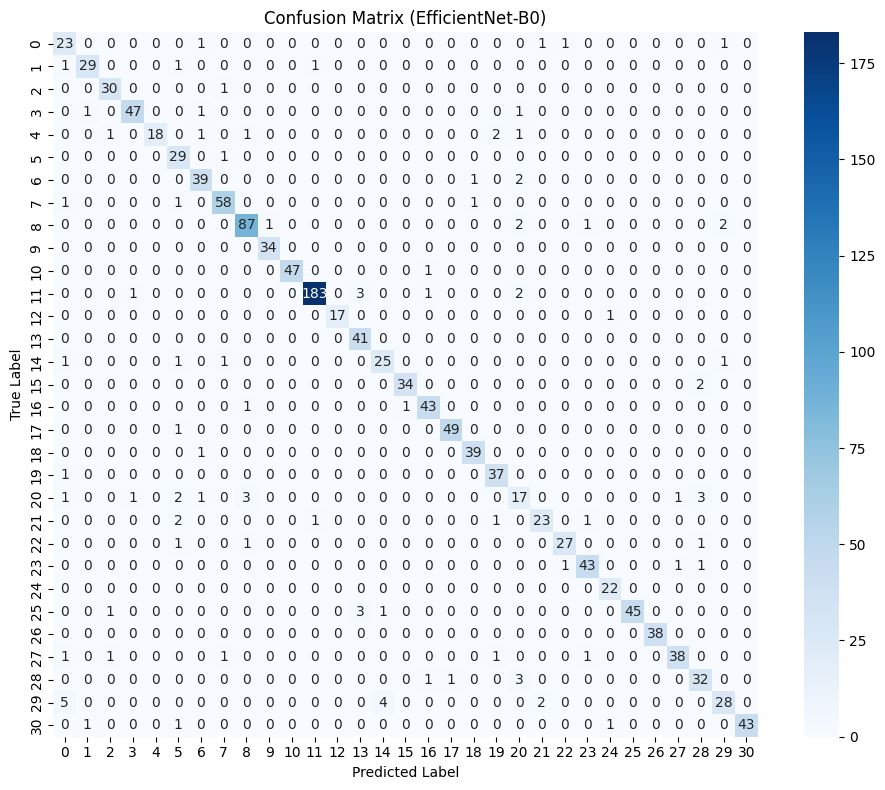

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# === Generate confusion matrix ===
cm = confusion_matrix(y_true, y_pred)
num_classes = cm.shape[0]

# === Plot ===
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=np.arange(num_classes),
            yticklabels=np.arange(num_classes),
            linewidths=0, linecolor='white', square=True)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (EfficientNet-B0)")
plt.tight_layout()
plt.show()


In [3]:
import os
import torch
import timm
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# === Paths ===
folder_path = r"C:\Users\STUDENT\Downloads\test_images"
model_path = "final_efficientnet_model.pth"  # ✅ Final trained model
class_names = sorted(os.listdir(r"C:\Users\STUDENT\Downloads\FishDataset_Split/train"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Image Transform ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ✅ EfficientNet uses 224x224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Load Model ===
model = timm.create_model("efficientnet_b0", pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, len(class_names))
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# === Inference on Folder ===
print(f"🔍 Predicting classes for images in: {folder_path}\n")

for filename in os.listdir(folder_path):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    try:
        img_path = os.path.join(folder_path, filename)
        image = Image.open(img_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probs = F.softmax(output, dim=1)
            prob, pred = torch.max(probs, 1)

        predicted_class = class_names[pred.item()]
        confidence = prob.item() * 100

        print(f"📷 {filename} → Predicted: {predicted_class} ({confidence:.2f}%)")

        # Optional: show image with prediction
        # plt.imshow(image)
        # plt.title(f"{predicted_class} ({confidence:.1f}%)")
        # plt.axis('off')
        # plt.show()

    except Exception as e:
        print(f"⚠️ Error processing {filename}: {e}")


🔍 Predicting classes for images in: C:\Users\STUDENT\Downloads\test_images

📷 1.jpg → Predicted: Bangus (99.97%)
📷 2.jpg → Predicted: Bangus (99.97%)
📷 4.jpg → Predicted: Gold Fish (99.99%)
📷 5.jpg → Predicted: Freshwater Eel (98.62%)
📷 6.jpg → Predicted: Gourami (99.81%)
📷 7.jpg → Predicted: Gold Fish (99.91%)
